In [2]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import norm
import pandas as pd
from scipy import stats
from itertools import product
from scipy import linalg
from functools import partial

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork, BernoulliNetwork
from src.metrics import (
    TrueRejection,
    FalseRejection,
    Rejection,
    RelativeFrobeniusNorm,
    ComputeAll,
    RobustRelativeProcrustesDistance
)

from src.helper_functions._metrics_helper import rv_coefficient, rv_coefficient_adjusted, cvm_stat_multivariate

from src.methods import (
    PermutationTest,
    RVPermutationTest,
    FitIndependent,
    LLKRatioTest,
    DiffusionCorrelation,
    CanonicalCorrelationTest,
    QAP
)
from src.solvers.binary_network import MLE_logistic
from src.solvers.MaMa_uuuuu import pgd_fit_wrapper, pgd_fit
from src.solvers.weighted_network import MLE_gaussian, ASE
from src.helper_functions.simulation_functions import run_simulation
from src.helper_functions.analyse_functions import aggregate_results
from src.helper_functions.plot_functions import plot_grid, plot_with_bands
import scipy.stats as stats
from src.helper_functions.plot_functions import visualise_latent
from functools import partial

In [2]:
import numpy as np

def compute_cvm_dependency(A, B):
    """
    Computes the Cramér-von Mises copula dependency measure between two graphs
    based on the joint empirical CDF of their shared neighbor matrices.
    
    Parameters:
    A, B : numpy.ndarray
        Binary adjacency matrices of the two graphs (shape N x N).
        
    Returns:
    float
        The Cramér-von Mises statistic.
    """
    N = A.shape[0]
    
    # 1. Compute shared neighbor matrices
    S_A = A @ A
    S_B = B @ B
    
    # 2. Extract upper triangular off-diagonal elements (undirected pairs)
    # This prevents double-counting edges and ignores the diagonal (self-loops)
    row_idx, col_idx = np.triu_indices(N, k=1)
    vals_A = S_A[row_idx, col_idx]
    vals_B = S_B[row_idx, col_idx]
    
    M = len(vals_A) # Total number of node pairs: N*(N-1)/2
    
    # 3. Build a 2D histogram of the pairs
    # Since shared neighbors are discrete integers bounded by N, 
    # the histogram perfectly captures the joint distribution.
    max_a = int(np.max(vals_A))
    max_b = int(np.max(vals_B))
    
    bins_a = np.arange(max_a + 2)
    bins_b = np.arange(max_b + 2)
    
    counts, _, _ = np.histogram2d(vals_A, vals_B, bins=(bins_a, bins_b))
    
    # 4. Compute Joint and Marginal PDFs
    pdf_joint = counts / M
    pdf_A = np.sum(pdf_joint, axis=1)
    pdf_B = np.sum(pdf_joint, axis=0)
    
    # 5. Compute Joint and Marginal CDFs via cumulative sums
    cdf_joint = np.cumsum(np.cumsum(pdf_joint, axis=0), axis=1)
    cdf_A = np.cumsum(pdf_A)
    cdf_B = np.cumsum(pdf_B)
    
    # 6. Compute the Cramér-von Mises statistic
    # Calculate the product of the marginals: F_A(x) * F_B(y)
    cdf_product = np.outer(cdf_A, cdf_B)
    
    # Calculate the squared difference between Joint CDF and the Independent CDF
    squared_diff = (cdf_joint - cdf_product)**2
    
    # The CvM statistic is the expectation of this squared difference over all observed pairs.
    # We weight the squared difference by the empirical frequency (counts) of each bin.
    cvm_statistic = np.sum(counts * squared_diff) / M
    
    return cvm_statistic



In [3]:
N = 100
    
# Generate two random binary symmetric matrices (dummy graphs)
A = np.random.binomial(1, 0.1, size=(N, N))
A = np.triu(A, 1)
A = A + A.T

# Make B heavily dependent on A to test if the statistic catches it
B = A.copy()
# Add some noise to B by flipping 5% of the edges
noise = np.random.binomial(1, 0.05, size=(N, N))
noise = np.triu(noise, 1)
noise = noise + noise.T
B = np.logical_xor(B, noise).astype(int)

# Generate an entirely independent graph C
C = np.random.binomial(1, 0.1, size=(N, N))
C = np.triu(C, 1)
C = C + C.T

cvm_dependent = compute_cvm_dependency(A, B)
cvm_independent = compute_cvm_dependency(A, C)

print(f"CvM Statistic (Highly Dependent graphs): {cvm_dependent:.6f}")
print(f"CvM Statistic (Independent graphs):      {cvm_independent:.6f}")

CvM Statistic (Highly Dependent graphs): 0.005983
CvM Statistic (Independent graphs):      0.000001


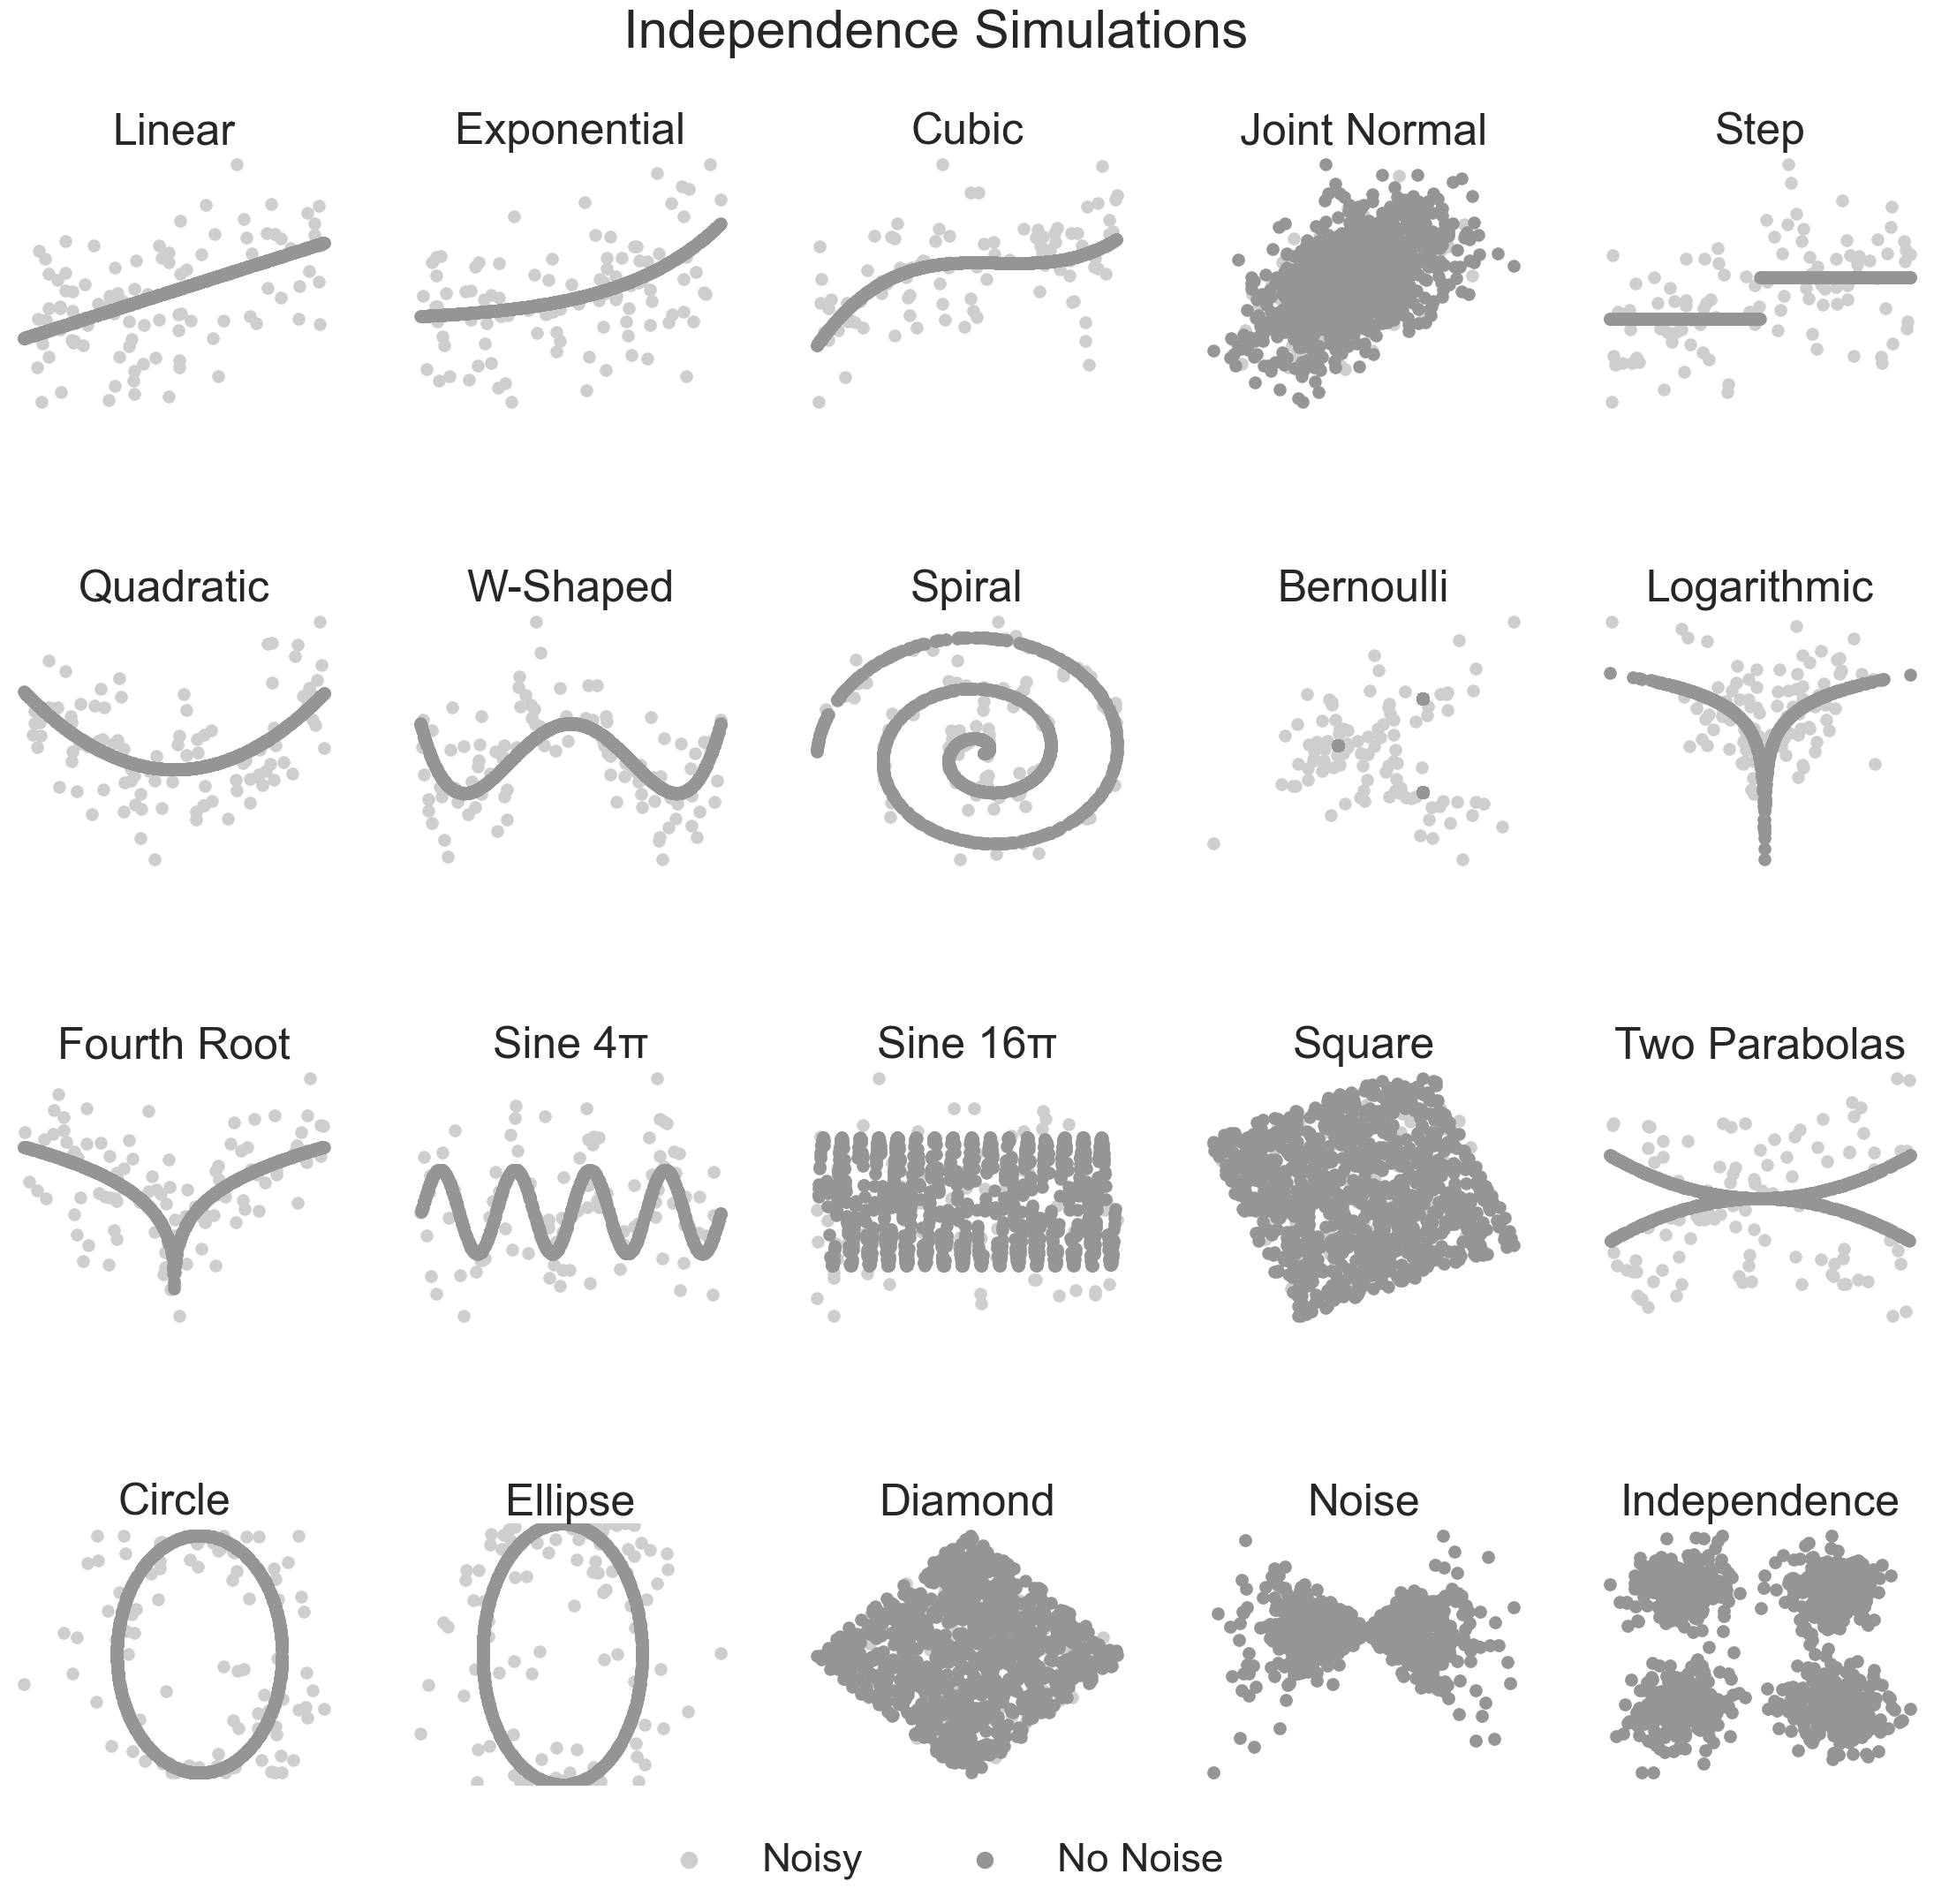

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from hyppo.tools import SIMULATIONS

# make plots look pretty
sns.set(color_codes=True, style="white", context="talk", font_scale=2)
PALETTE = sns.color_palette("Greys", n_colors=9)
sns.set_palette(PALETTE[2::2])

# constants
NOISY = 100  # sample size of noisy simulation
NO_NOISE = 1000  # sample size of noise-free simulation

# simulation titles
SIM_TITLES = [
    "Linear",
    "Exponential",
    "Cubic",
    "Joint Normal",
    "Step",
    "Quadratic",
    "W-Shaped",
    "Spiral",
    "Bernoulli",
    "Logarithmic",
    "Fourth Root",
    "Sine 4\u03C0",
    "Sine 16\u03C0",
    "Square",
    "Two Parabolas",
    "Circle",
    "Ellipse",
    "Diamond",
    "Noise",
    "Independence",
]


fig, ax = plt.subplots(nrows=4, ncols=5, figsize=(28, 24))

plt.suptitle("Independence Simulations", y=0.93, va="baseline")

for i, row in enumerate(ax):
    for j, col in enumerate(row):
        count = 5 * i + j
        sim_title = SIM_TITLES[count]
        
        sim = list(SIMULATIONS.values())[count]

        # the multiplicative noise and independence simulation don't have a noise
        # parameter
        if sim_title in ["Noise", "Independence"]:
            x, y = sim(NO_NOISE, 1)
            x_no_noise, y_no_noise = x, y
        else:
            x, y = sim(NOISY, 1, noise=True)
            x_no_noise, y_no_noise = sim(NO_NOISE, 1)

        # plot the noise and noise-free sims
        col.scatter(x, y, label="Noisy")
        col.scatter(x_no_noise, y_no_noise, label="No Noise")

        # make the plot look pretty
        col.set_title("{}".format(sim_title))
        col.set_xticks([])
        col.set_yticks([])
        if count == 16:
            col.set_ylim([-1, 1])
        sns.despine(left=True, bottom=True, right=True)

leg = plt.legend(
    bbox_to_anchor=(0.5, 0.1),
    bbox_transform=plt.gcf().transFigure,
    ncol=5,
    loc="upper center",
)
leg.get_frame().set_linewidth(0.0)
for legobj in leg.legend_handles:
    legobj.set_linewidth(5.0)
plt.subplots_adjust(hspace=0.75)

In [23]:
list(SIMULATIONS.values())[0]

<function hyppo.tools.indep_sim.linear(n, p, noise=False, low=-1, high=1)>

In [3]:
m = GaussianNetwork(n=100, k=3, rho=0, marginals='cauchy', center_latent=True, self_loops=False)
data = m.generate()

(array([  2.,   4., 279.,  12.,   1.,   1.,   0.,   0.,   0.,   1.]),
 array([-77.87341272, -49.82414332, -21.77487392,   6.27439548,
         34.32366488,  62.37293428,  90.42220368, 118.47147308,
        146.52074248, 174.57001188, 202.61928128]),
 <BarContainer object of 10 artists>)

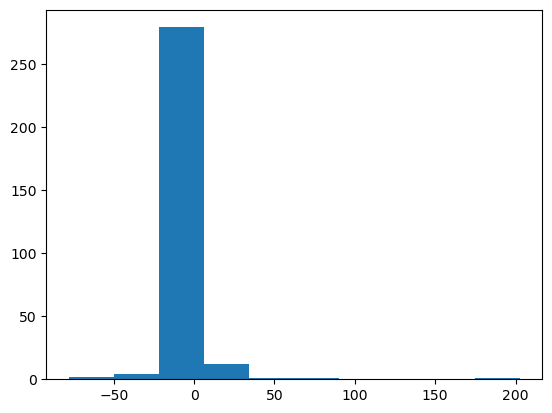

In [4]:
plt.hist((data['Z']).flatten())

In [5]:
out = MLE_gaussian(data['A'], k=3)

In [6]:
RobustRelativeProcrustesDistance()({'estimated_latent':out[0], 'true_latent':data['Z']})

[np.float64(0.36823708665894367)]

(array([  3.,   0.,   7., 255.,  29.,   1.,   3.,   1.,   0.,   1.]),
 array([-64.98708842, -48.36935197, -31.75161553, -15.13387908,
          1.48385737,  18.10159381,  34.71933026,  51.3370667 ,
         67.95480315,  84.5725396 , 101.19027604]),
 <BarContainer object of 10 artists>)

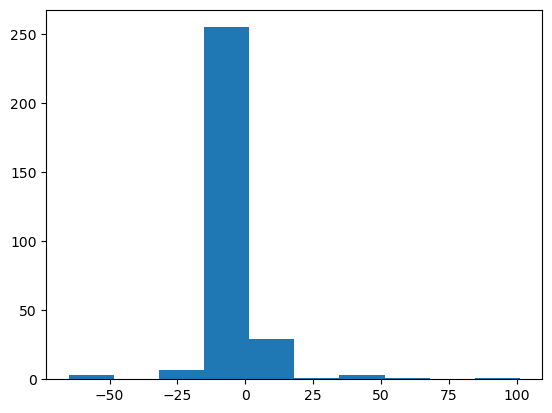

In [7]:
plt.hist((out[0]).flatten())

In [8]:
def relative_l1_error(A_true, A_est):
    """
    Calculates the Relative L1 Norm between the true matrix and the estimate.
    Highly robust for heavy-tailed (Cauchy) distributions.
    
    Parameters:
    A_true (np.ndarray): The ground truth matrix
    A_est (np.ndarray): The estimated matrix
    
    Returns:
    float: The relative error (0.0 means perfect reconstruction)
    """
    # Calculate the absolute element-wise difference (L1 of the error)
    abs_diff = np.sum(np.abs(A_true - A_est))
    
    # Calculate the sum of absolute values of the truth (L1 of the truth)
    abs_true = np.sum(np.abs(A_true))
    
    # Avoid division by zero if A_true is all zeros
    if abs_true == 0:
        return np.inf if abs_diff > 0 else 0.0
        
    return abs_diff / abs_true

In [9]:
nsim = 25
n = [50, 200, 300, 600]
k = [3]
rho = [0]
alpha = [0.05]
marginals = ['cauchy', 'gaussian', 't 3', 'uniform -1 1']
edge_var = [1]

method = [
    # partial(RVPermutationTest, permutation_type="latent"),
    # partial(RVPermutationTest, permutation_type="observed"),
    # LLKRatioTest,
    # QAP,
    # DiffusionCorrelation,
    # partial(CanonicalCorrelationTest, permutation_type="latent"),
    # partial(CanonicalCorrelationTest, permutation_type="observed"),
    FitIndependent
]

npermutations = [100]
metrics = [ComputeAll()]
approximation = ["F-distr"]

solver = partial(MLE_gaussian, k=3)

model = partial(GaussianNetwork, center_latent=True, self_loops=False)

setup = [
    (model, partial(MLE_gaussian, k=3)),
    (model, partial(ASE, k=3)),
]

rng = np.random.default_rng(0)    

param_names = [
    "setup",
    "method",
    "n",
    "k",
    "rho",
    "alpha",
    "marginals",
    "edge_var",
    "approximation",
    "npermutations"
]

param_values = product(
    setup, method, n, k, rho, alpha, marginals, edge_var, approximation, npermutations
)

factorial_design = [dict(zip(param_names, v)) for v in param_values]

out = run_simulation(
    nsim=nsim,
    metrics=metrics,
    factorial_design=factorial_design,
    rng=rng,
    parallel=True,
)

out = pd.DataFrame(out)

Running scenarios: 100%|██████████| 800/800 [01:59<00:00,  6.67it/s]


In [10]:
out["n"] = out["args"].apply(lambda x: x["n"])
out["k"] = out["args"].apply(lambda x: x["k"])
out["edge_var"] = out["args"].apply(lambda x: x.get("edge_var", "NA"))
out["approximation"] = out["args"].apply(lambda x: x.get("approximation", "NA"))
out["dgp"] = out["args"].apply(lambda x: x["setup"][0].func.__name__)
out["solver"] = out["args"].apply(lambda x: x["setup"][1].func.__name__)
out['rho'] = out["args"].apply(lambda x: x.get("rho", "NA"))

out["method"] = out["args"].apply(lambda x: x.get("method_name", "NA"))

out["marginals"] = out["args"].apply(lambda x: x.get("marginals", "NA"))

In [11]:
# out["FalseRejection"] = out["ComputeAll"].apply(lambda x: x["FalseRejection"])
# out["TrueRejection"] = out["ComputeAll"].apply(lambda x: x["TrueRejection"])
# out["Rejection"] = out["ComputeAll"].apply(lambda x: x["Rejection"])
out['RelativeFrobeniusNorm_x'] = out["ComputeAll"].apply(lambda x: x["RelativeFrobeniusNorm_x"])
out['ProcrustesDistance_x'] = out["ComputeAll"].apply(lambda x: x["ProcrustesDistance_x"])
out['RelativeFrobeniusNorm_z'] = out["ComputeAll"].apply(lambda x: x["RelativeFrobeniusNorm_z"])
out['ProcrustesDistance_z'] = out["ComputeAll"].apply(lambda x: x["ProcrustesDistance_z"])

In [12]:
results_gaussian = out[out["dgp"] == "GaussianNetwork"]
results_bernoulli = out[out["dgp"] == "BernoulliNetwork"]

results_null_gaussian = results_gaussian[results_gaussian["rho"] == 0]
results_null_bernoulli = results_bernoulli[results_bernoulli["rho"] == 0]

results_null_gaussian_rv = results_null_gaussian[
    results_null_gaussian["method"] == "RVPermutationTest"
]
results_null_gaussian_llk = results_null_gaussian[
    results_null_gaussian["method"] == "LLKRatioTest"
]

results_05_gaussian = out[
    (out['dgp'] == "GaussianNetwork") & (out['rho'] == 0.5)
]

In [13]:
agg_gaussian_x = aggregate_results(
    results_gaussian,
    y_axis="RelativeFrobeniusNorm_x",
    x_axis="n",
    factors=["marginals", "solver", "method"],
)

# agg_gaussian_x = aggregate_results(
#     results_gaussian,
#     y_axis="RelativeFrobeniusNorm_x",
#     x_axis="n",
#     factors=["marginals", "solver", "method"],
# )
# agg_gaussian_z = aggregate_results(
#     results_gaussian,
#     y_axis="RelativeFrobeniusNorm_z",
#     x_axis="n",
#     factors=["edge_var", "k", "solver"],
# )
# agg_bernoulli_x = aggregate_results(
#     results_bernoulli,
#     y_axis="RelativeFrobeniusNorm_x",
#     x_axis="n",
#     factors=["edge_var", "k", "solver"],
# )
# agg_bernoulli_z = aggregate_results(
#     results_bernoulli,
#     y_axis="RelativeFrobeniusNorm_z",
#     x_axis="n",
#     factors=["edge_var", "k", "solver"],
# )

# agg_gaussian_null = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="n",
#     factors=["marginals", "solver", "method"],
# )

agg_05_gaussian = aggregate_results(
    results_05_gaussian,
    y_axis="RelativeFrobeniusNorm_x",
    x_axis="n",
    factors=["marginals", "solver", "method"],
)

agg_bernoulli_null = aggregate_results(
    results_null_bernoulli,
    y_axis="RelativeFrobeniusNorm_x",
    x_axis="n",
    factors=["marginals", "solver", "method"],
)

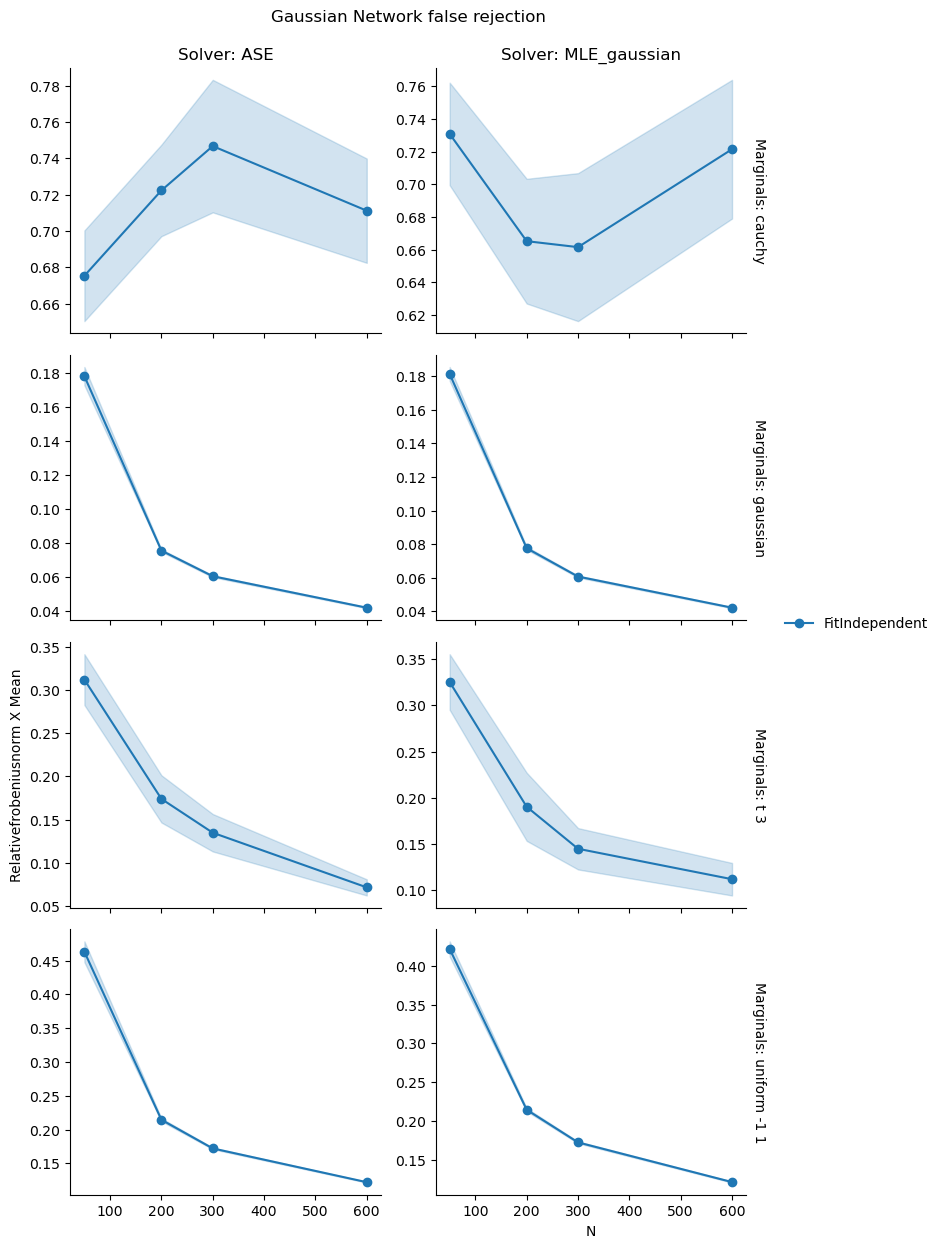

In [14]:
plot_grid(
    grouped_stats=agg_gaussian_x,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_x_mean",
    factors=["method", "solver", "marginals"],
    height=3,
    se_bands="RelativeFrobeniusNorm_x_sem",
    share_x=True,
    share_y=False,
    title="Gaussian Network false rejection",
)

In [15]:
1/0

ZeroDivisionError: division by zero

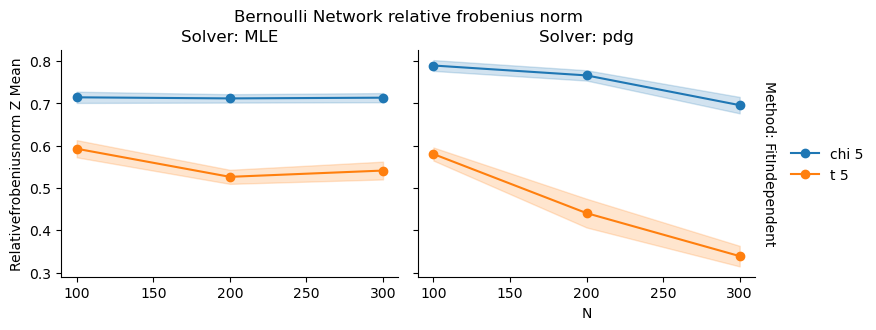

: 

: 

In [ ]:
plot_grid(
    grouped_stats=agg_bernoulli_null[agg_bernoulli_null['marginals']!= 'beta 2 5'],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_z_mean",
    factors=["marginals", "solver", "method"],
    height=3,
    se_bands="RelativeFrobeniusNorm_z_sem",
    share_x=True,
    share_y=True,
    title="Bernoulli Network relative frobenius norm",
)

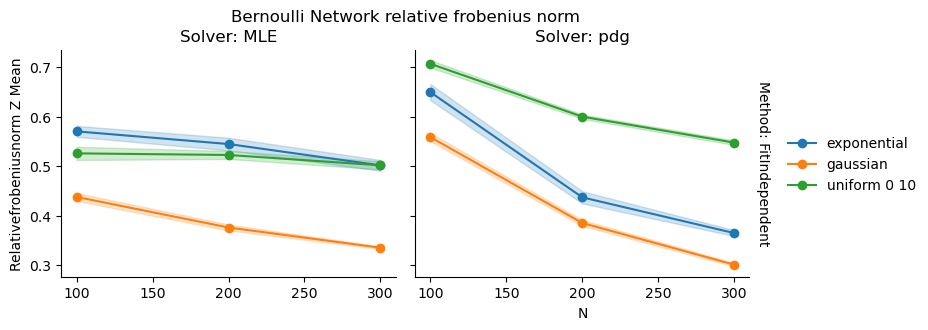

: 

: 

In [ ]:
plot_grid(
    grouped_stats=agg_bernoulli_null,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_z_mean",
    factors=["marginals", "solver", "method"],
    height=3,
    se_bands="RelativeFrobeniusNorm_z_sem",
    share_x=True,
    share_y=True,
    title="Bernoulli Network relative frobenius norm",
)

In [ ]:
plot_grid(
    grouped_stats=agg_gaussian_null,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["k", "edge_var", "solver"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=False,
    title="Gaussian Network false rejection rate",
)

plot_grid(
    grouped_stats=agg_bernoulli_null,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["k", "edge_var", "solver"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=False,
    title="Bernoulli Network false rejection rate",
)

KeyError: 'solver'

: 

: 

### Logistic rdpg solver

In [ ]:
nsim = 100
n = 100
k = 2
rho = 0
false_rej = 0
for i in range(nsim):
    rng = np.random.default_rng()

    md = GaussianNetwork(n=n, k=k, rho=rho, rng=rng, edge_var=1)

    A, B, X, Z = md.generate()

    method = RVPermutationTest(rng=rng, shrink=0, solver=MLE_gaussian, rho=rho)

    method.fit(A, B=B, X=X, Z=Z, rv_coefficient_function=rv_coefficient_adjusted)

    estimated = method.get_estimated()
    truth = method.get_truth()

    false_rej += FalseRejection()(estimated, truth)

print(false_rej / nsim)

0.03


: 

: 

### Testing Logistic RDPG

In [ ]:
nsim = 200
n = [10, 25, 50, 100, 200, 300]
k = [2, 5]
rho = [0, 0.1]
alpha = [0.05]
marginal_z = [stats.norm]
marginal_x = [stats.norm]
marginal_x_params = [{"a": 2, "b": 5}]
marginal_z_params = [{"a": 2, "b": 5}]
solver = [MLE_gaussian]
edge_var = [1, 3, 5]
dgp = [GaussianNetwork]
methods = [RVPermutationTest]
metrics = [FalseRejection(), TrueRejection(), Rejection()]
rv_coefficient_function = [rv_coefficient_adjusted, rv_coefficient]

rng = np.random.default_rng(1)

param_names = [
    "dgp",
    "method",
    "n",
    "k",
    "rho",
    "alpha",
    "marginal_z",
    "marginal_x",
    "edge_var",
    "solver",
    "rv_coefficient_function",
]

param_values = product(
    dgp,
    methods,
    n,
    k,
    rho,
    alpha,
    marginal_z,
    marginal_x,
    edge_var,
    solver,
    rv_coefficient_function,
)

factorial_design = [dict(zip(param_names, v)) for v in param_values]

out = run_simulation(
    nsim=nsim,
    metrics=metrics,
    factorial_design=factorial_design,
    rng=rng,
    parallel=True,
)

Running scenarios: 100%|██████████| 28800/28800 [00:57<00:00, 498.96it/s]


: 

: 

In [ ]:
out = pd.DataFrame(out)
out["n"] = out["args"].apply(lambda x: x["n"])
out["k"] = out["args"].apply(lambda x: x["k"])
out["edge_var"] = out["args"].apply(lambda x: x["edge_var"])

out["dgp"] = out["args"].apply(lambda x: str(x["dgp"].__name__))

out["solver"] = out["args"].apply(lambda x: str(x["solver"].__name__))
out["rho"] = out["args"].apply(lambda x: x["rho"])
out["method"] = out["args"].apply(lambda x: str(x["method"].__name__))
out["rv_coefficient_function"] = out["args"].apply(
    lambda x: str(x["rv_coefficient_function"].__name__)
)

: 

: 

In [ ]:
out_null = out[out["rho"] == 0]
out_alt = out[out["rho"] != 0]

: 

: 

In [ ]:
agg_out_null = aggregate_results(
    out_null,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["edge_var", "k", "rv_coefficient_function"],
)
agg_out_alt = aggregate_results(
    out_alt,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "rv_coefficient_function"],
)

: 

: 

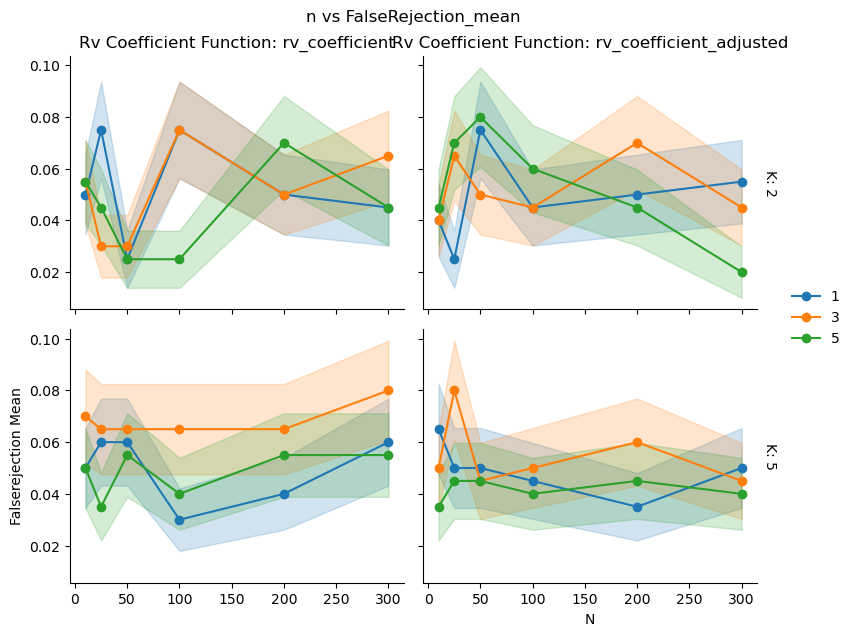

: 

: 

In [ ]:
plot_grid(
    grouped_stats=agg_out_null,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["edge_var", "rv_coefficient_function", "k"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
)

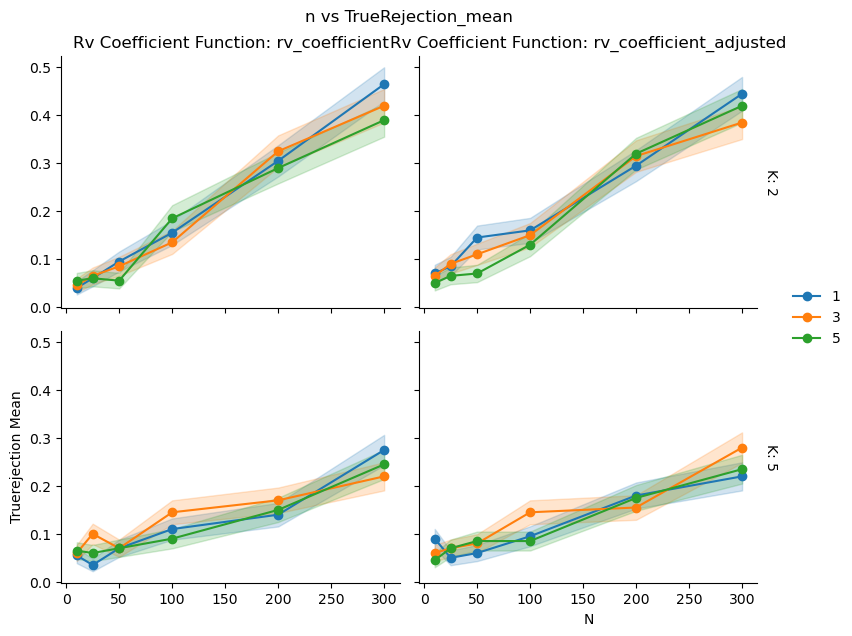

: 

: 

In [ ]:
plot_grid(
    grouped_stats=agg_out_alt,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["edge_var", "rv_coefficient_function", "k"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=True,
)

In [ ]:
1 / 0

ZeroDivisionError: division by zero

: 

: 

## NORM results

In [ ]:
out = pd.DataFrame(out)
out["n"] = out["args"].apply(lambda x: x["n"])
out["k"] = out["args"].apply(lambda x: x["k"])
out["edge_var"] = out["args"].apply(lambda x: x["edge_var"])

out["dgp"] = out["args"].apply(lambda x: str(x["dgp"].__name__))

out["RelativeFrobeniusNorm_z"] = out["RelativeFrobeniusNorm"].apply(lambda x: x[1])
out["RelativeFrobeniusNorm_x"] = out["RelativeFrobeniusNorm"].apply(lambda x: x[0])

out["solver"] = out["args"].apply(lambda x: str(x["solver"].__name__))

: 

: 

In [ ]:
out_gaussian = out[out["dgp"] == "GaussianNetwork"]
out_bernoulli = out[out["dgp"] == "BernoulliNetwork"]

out_x_gaussian = out_gaussian.drop(
    columns=["RelativeFrobeniusNorm", "RelativeFrobeniusNorm_z"]
)
out_x_bernoulli = out_bernoulli.drop(
    columns=["RelativeFrobeniusNorm", "RelativeFrobeniusNorm_z"]
)

out_z_gaussian = out_gaussian.drop(
    columns=["RelativeFrobeniusNorm", "RelativeFrobeniusNorm_x"]
)
out_z_bernoulli = out_bernoulli.drop(
    columns=["RelativeFrobeniusNorm", "RelativeFrobeniusNorm_x"]
)

out_x_gaussian_ase = out_x_gaussian[out_x_gaussian["solver"] == "ASE"]
out_x_gaussian_mle = out_x_gaussian[out_x_gaussian["solver"] == "MLE_gaussian"]
out_x_gaussian_mle_logistic = out_x_gaussian[out_x_gaussian["solver"] == "MLE_logistic"]

out_x_bernoulli_ase = out_x_bernoulli[out_x_bernoulli["solver"] == "ASE"]
out_x_bernoulli_mle = out_x_bernoulli[out_x_bernoulli["solver"] == "MLE_gaussian"]
out_x_bernoulli_mle_logistic = out_x_bernoulli[
    out_x_bernoulli["solver"] == "MLE_logistic"
]

: 

: 

In [ ]:
agg_out_z_gaussian = aggregate_results(
    out_z_gaussian,
    y_axis="RelativeFrobeniusNorm_z",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_out_x_gaussian = aggregate_results(
    out_x_gaussian,
    y_axis="RelativeFrobeniusNorm_x",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_out_x_bernoulli = aggregate_results(
    out_x_bernoulli,
    y_axis="RelativeFrobeniusNorm_x",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_out_z_bernoulli = aggregate_results(
    out_z_bernoulli,
    y_axis="RelativeFrobeniusNorm_z",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)

: 

: 

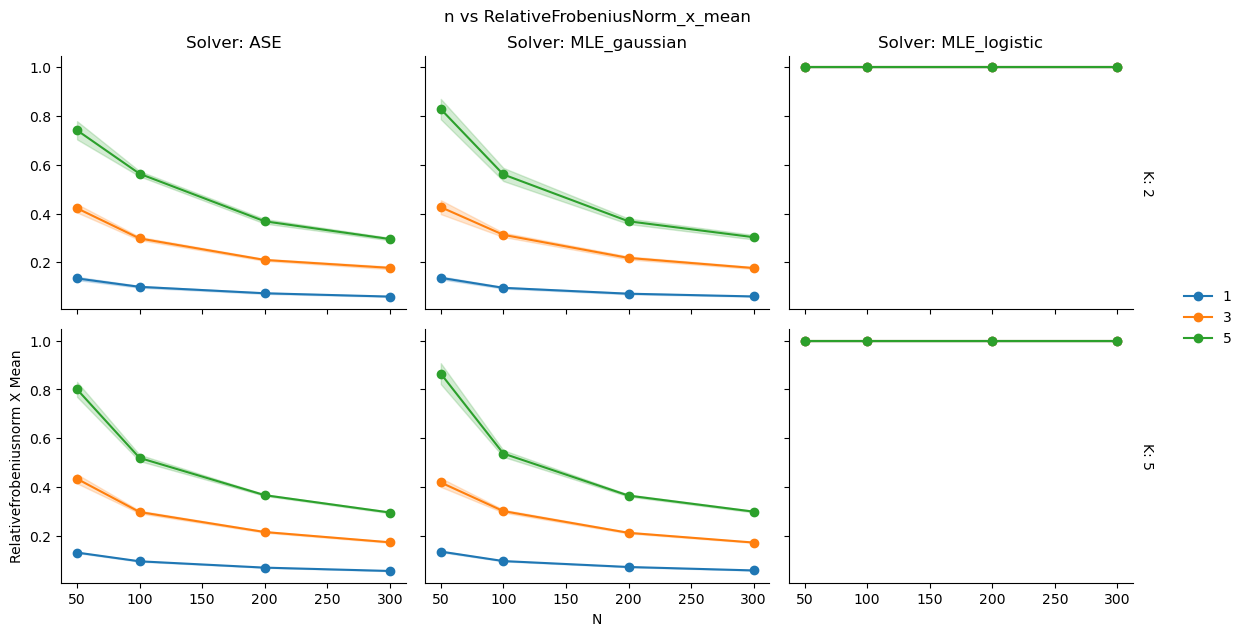

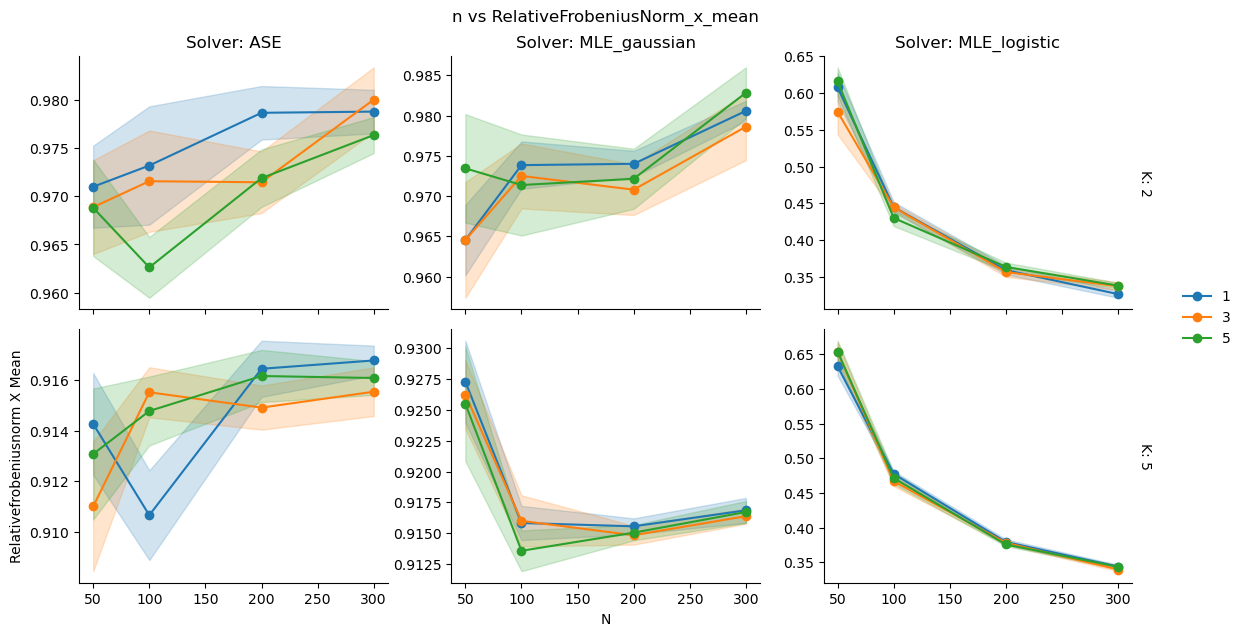

: 

: 

In [ ]:
from src.plot_functions import plot_grid, plot_with_bands

plot_grid(
    grouped_stats=agg_out_x_gaussian,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_x_mean",
    factors=["edge_var", "solver", "k"],
    height=3,
    se_bands="RelativeFrobeniusNorm_x_sem",
    share_x=True,
    share_y=True,
)

plot_grid(
    grouped_stats=agg_out_x_bernoulli,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_x_mean",
    factors=["edge_var", "solver", "k"],
    height=3,
    se_bands="RelativeFrobeniusNorm_x_sem",
    share_x=True,
    share_y=False,
)

In [ ]:
1 / 0


def logistic_grad(params, X, y, mu=None):
    """Utility function for scipy optimizer returning loss and gradient for logistic regression"""
    if mu is None:
        coef = params[:-1]
        mu = params[-1]
    else:
        coef = params

    logits = X @ coef + mu
    loss = np.sum(np.logaddexp(0, logits) - y * logits)
    p = expit(logits)
    error = p - y
    grad_w = X.T @ error
    return loss, grad_w


def solve_logistic_scipy(X, y, mu=None):
    """Solve logistic regression with (possibly) fixed intercept and positive coefficients

    Parameters
    ----------
    X : np.ndarray
        Feature matrix
    y : np.ndarray
        Target vector
    mu : float, optional
        Intercept term, by default None. If None estimate it

    Returns
    -------
    np.ndarray
        Coefficients of the logistic regression
    float
        Intercept term
    """

    n_samples, n_features = X.shape

    if mu is None:
        initial_params = np.zeros(n_features + 1)
        bounds = [(0, None)] * n_features + [(None, None)]
        # jac=True tells scipy the objective function returns (loss, gradient)
        res = minimize(
            logistic_grad,
            initial_params,
            args=(X, y),
            method="L-BFGS-B",
            bounds=bounds,
            jac=True,
        )
    else:
        initial_params = np.zeros(n_features)
        bounds = [(0, None)] * n_features
        # jac=True tells scipy the objective function returns (loss, gradient)
        res = minimize(
            logistic_grad,
            initial_params,
            args=(X, y, mu),
            method="L-BFGS-B",
            bounds=bounds,
            jac=True,
        )

    return res.x[:n_features], res.x[-1] if mu is None else mu


def MLE_logistic(A, k=2, rng=None, shrink=0, **kwargs):
    # print("WARNING: MLE_logistic is experimental and might not work as expected.")
    """Maximum Likelihood Estimation for Logistic link adjacency matrix

    Parameters
    ----------
    A : np.ndarray
        Adjacency matrix
    k : int, optional
        Number of latent dimensions, by default 2
    rng : np.random.Generator, optional
        Random number generator, by default None
    shrink : int, optional
        Shrinkage parameter, by default 0

    Returns
    -------
    _type_
        _description_
    """
    if rng is None:
        rng = np.random.default_rng()

    # useful quantities
    n = A.shape[0]

    # in the paper it seems to use the frob norm NOT squared, i get better results
    # squaring it
    a_norm_scaled = 1 / (n * (n - 1)) * norm(A, "fro") ** 2

    # mean centered matrix
    A_centered = A - a_norm_scaled

    # from paper, mle of \mu
    mu_hat = -np.log(a_norm_scaled / (1 - a_norm_scaled))

    # use this to fix randomness in eigsh
    v0 = rng.standard_normal(size=A_centered.shape[0])

    evals, evectors = eigsh(A_centered, k=k, which="LM", v0=v0)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evectors = evectors[:, idx]

    # build the matrix of features
    X_big = np.zeros((n * (n - 1) // 2, k))

    for i in range(k):
        t = np.outer(evectors[:, i], evectors[:, i])
        X_big[:, i] = t[np.triu_indices(n, k=1)]

    # define as target the upper diagonal part of A (equal to lower since
    # A symmetric)
    target = A[np.triu_indices(n, k=1)]

    # solve logistic regression with fixed mu and positive constrained coefs
    coefs, mu = solve_logistic_scipy(X_big, target, mu=mu_hat)

    xhat = evectors * np.sqrt(coefs)

    return [xhat], [evals]

ZeroDivisionError: division by zero

: 

: 